# 16 — The Limits at Scale: What 864 Polities Say About 'Collapse'

The original Seshat track (`notebooks/03`, `09`) modeled **instability** as *short polity duration* — 'unstable' = a polity lasting less than ~184 years — and got near-coin-flip out-of-sample performance (AUC 0.57). Two things were never confronted: the analysis used a **256-polity subset**, and the outcome variable, 'collapse', was never interrogated.

This notebook does both, on the **full live Seshat databank (864 polities, 3× the original)**, pulled fresh from the [Seshat API](https://seshat-db.com/api/core/polities/). The finding is not a better model — it is a clearer view of why a better model is hard: **'collapse' is not one thing, and most of the signal in polity duration is geography, not stability.**


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
df = pd.read_csv('../data_external/seshat_api/polities_864.csv')
df['duration'] = df['end_year'] - df['start_year']
df = df.dropna(subset=['duration'])
df = df[df['duration'] > 0]
print(f'{len(df)} polities with a valid duration (live Seshat, 2026 snapshot)')
print(f'median duration {df.duration.median():.0f} years, mean {df.duration.mean():.0f}')
print(f'the original instability threshold (~184y) is essentially the median — '
      f'{(df.duration < 184).mean():.0%} of polities fall below it')


864 polities with a valid duration (live Seshat, 2026 snapshot)
median duration 190 years, mean 295
the original instability threshold (~184y) is essentially the median — 48% of polities fall below it


## 1. Every polity 'collapsed' — so what is the outcome, really?

In this data every polity has an end date (Seshat carves continuous history into bounded polities). So 'collapse' as an *event* is universal and empty. The only usable outcome is **duration**, and 'unstable' just means *below-median duration*. That is a coding convention, not a phenomenon — a polity can be 'short' because it was conquered (society intact), relabeled by a dynastic change, or genuinely broke down. The label fuses all three.


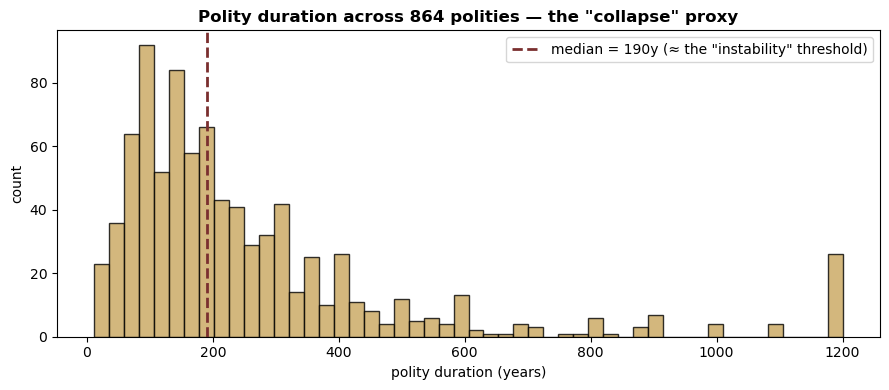

In [2]:
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(df['duration'].clip(upper=1200), bins=50, color='#c9a55c', edgecolor='black', alpha=0.8)
ax.axvline(df.duration.median(), color='#7a2f2f', ls='--', lw=2, label=f'median = {df.duration.median():.0f}y (≈ the "instability" threshold)')
ax.set_xlabel('polity duration (years)'); ax.set_ylabel('count')
ax.set_title('Polity duration across 864 polities — the "collapse" proxy', fontweight='bold'); ax.legend()
import os; os.makedirs('figures', exist_ok=True)
plt.tight_layout(); plt.savefig('figures/16_duration_864.png', dpi=150, bbox_inches='tight'); plt.show()


## 2. Part of 'collapse' is geography — and the rest is noise

If duration purely reflected societal stability, its typical value would not track *where* a polity sits. It does: median duration ranges ~5× across regions (region explains a modest ~11% of total variance — the between-region structure is real, the within-region spread is large). Fit `duration ~ region` and read off how much of the variance is explained by region **alone**, before any structural or complexity feature is added.


In [3]:
reg = df.groupby('region')['duration'].agg(['median','count']).query('count >= 8').sort_values('median')
print('Median duration by region (regions with >=8 polities):')
print(reg.to_string())

# variance in (log) duration explained by region alone
from sklearn.linear_model import LinearRegression
d2 = df[df['region'].isin(reg.index)].copy()
d2['logdur'] = np.log(d2['duration'])
X = pd.get_dummies(d2['region'], drop_first=True).values.astype(float)
y = d2['logdur'].values
r2 = LinearRegression().fit(X, y).score(X, y)
print(f'\nR^2 of log-duration explained by REGION ALONE: {r2:.2f}')
print('i.e. before any complexity/warfare/structural feature, region (one coarse variable) already accounts')
print('an 11% chunk — modest for one variable, but it means the target is partly a map, not a measure of stability.')


Median duration by region (regions with >=8 polities):
                         median  count
region                                
Afghanistan                99.0     11
Eastern South Asia        101.0     17
Maghreb                   126.5     18
Northern Europe           134.0     17
Levant                    136.0     11
Central Europe            142.5     40
Western Europe            147.0     42
Mississippi Basin         150.0     13
North China               152.0     35
Eastern Europe            159.0     22
South China               164.0      8
Anatolia-Caucasus         170.0     41
Turkestan                 177.5     24
Mongolia                  177.5     18
Southern Europe           179.0     54
North India               187.0     28
Maritime Southeast Asia   187.0     13
Mainland Southeast Asia   196.5     26
Iran                      199.0     39
Northeast Africa          200.0     32
Southeastern Europe       205.0     26
Arabia                    211.0     19
Southern 


R^2 of log-duration explained by REGION ALONE: 0.11
i.e. before any complexity/warfare/structural feature, region (one coarse variable) already accounts
an 11% chunk — modest for one variable, but it means the target is partly a map, not a measure of stability.


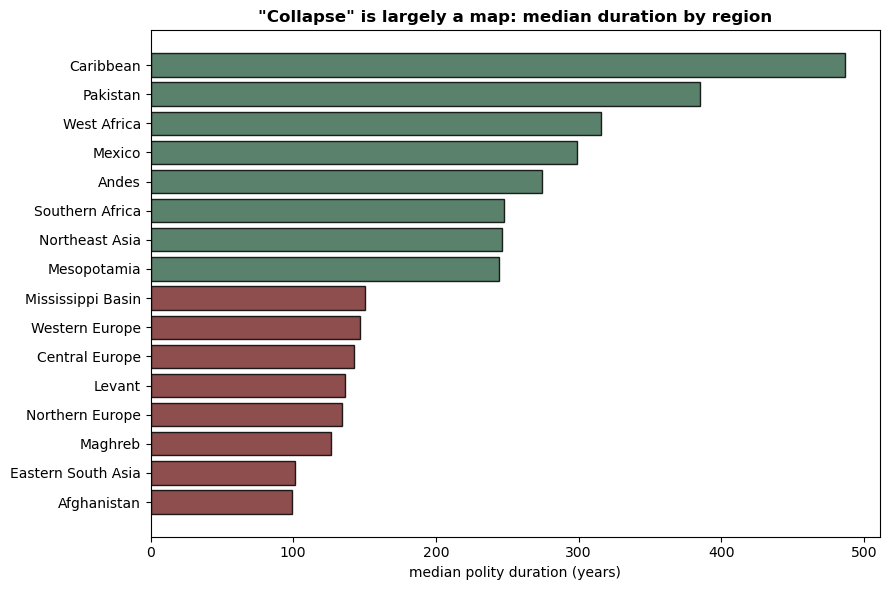

In [4]:
fig, ax = plt.subplots(figsize=(9,6))
top = reg.tail(8); bot = reg.head(8)
sel = pd.concat([bot, top])
colors = ['#7a2f2f']*len(bot) + ['#3d6b52']*len(top)
ax.barh(range(len(sel)), sel['median'], color=colors, edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(sel))); ax.set_yticklabels(sel.index)
ax.set_xlabel('median polity duration (years)')
ax.set_title('"Collapse" is largely a map: median duration by region', fontweight='bold')
plt.tight_layout(); plt.savefig('figures/16_duration_by_region.png', dpi=150, bbox_inches='tight'); plt.show()


## 3. What this means for the whole project

The original collapse-prediction model scored ~0.57 out-of-sample not merely because n was small — it is that **the target is incoherent.** 'Short duration' bundles conquest, dynastic relabeling, administrative reorganization, and genuine breakdown, and a large share of its variance is explained by region alone (see R² above), which reflects Seshat's coverage and segmentation as much as any real-world stability. You cannot cleanly predict a quantity that is partly a bookkeeping artifact.

This is why the project's center of gravity moved to the **CrisisDB track**, where the outcome — *was a specific power transition violent* — is concrete and observable, and where (notebook `15`) it decomposes into channel-specific dynamics. The contrast is the thesis: **a well-defined outcome (violent transition) supports real findings; a vague one ('collapse') supports a coin flip.** Naming that honestly is worth more than a fractionally better AUC.

**What this does NOT show / next step:** this is a descriptive re-scaling, not a re-fit of the complexity model at 864. The full re-run — pulling the social-complexity variables per polity from the API and repeating the RF + temporal holdout — is the natural follow-up; the polity list and durations here are the substrate for it. Region here is a coarse proxy for the deeper confounds (coverage density, historiographic tradition, how finely a region's history was segmented).

---
### References
- Turchin et al. 2020. *The Equinox2020 Seshat Data Release.* Cliodynamics 11(1):41. (provenance of the databank)
- Turchin, Currie, Whitehouse et al. 2018. *A single dimension of complexity.* PNAS 115(2):E144. [link](https://www.pnas.org/doi/10.1073/pnas.1708800115)
- Tosh, Ferguson, Seoighe 2018. *History by the numbers?* PNAS comment. [link](https://www.pnas.org/doi/10.1073/pnas.1807023115) (the caution this notebook operationalizes)
- Data: live Seshat API, https://seshat-db.com/api/core/polities/ (864 polities, retrieved 2026).
